# Comparative Scatter Plot: Male vs Female Author Bias

Updates applied:
- **Selective labeling**: only words with `|Male_Author_Bias| > 0.02` or `|Female_Author_Bias| > 0.02` are labeled.
- **Category color-coding** for easier trend spotting.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

data_path = Path('outputs') / 'task_male_female_bias_comparison.csv'
df = pd.read_csv(data_path)
df = df[['Attribute_Word', 'Category', 'Female_Author_Bias', 'Male_Author_Bias']].copy()

label_threshold = 0.02

print(f'Loaded {len(df)} rows from: {data_path}')
print(f'Label threshold: |bias| > {label_threshold}')
df.head()

Loaded 25 rows from: outputs\task_male_female_bias_comparison.csv
Label threshold: |bias| > 0.02


,Attribute_Word,Category,Female_Author_Bias,Male_Author_Bias
0,submissive,stereotype_traits,-0.066305,-0.021677
1,manager,professions,-0.038637,-0.005507
2,nurse,professions,-0.070489,-0.101362
3,strong,stereotype_traits,-0.006082,0.020051
4,imagination,arts,-0.009156,0.012821


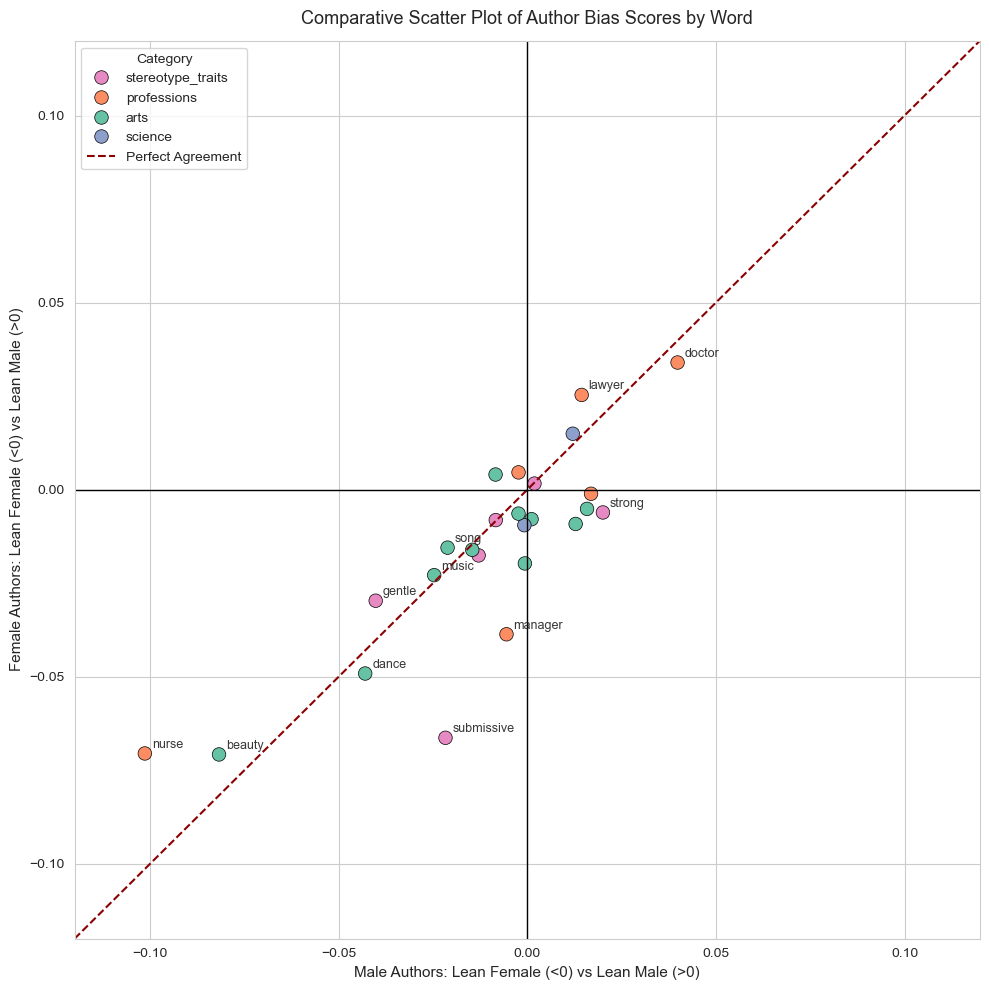

In [2]:
# Symmetric axis bounds, with a minimum of +/-0.12 for balanced visual space.
max_abs = float(np.abs(df[['Male_Author_Bias', 'Female_Author_Bias']].to_numpy()).max())
lim = max(0.12, round(max_abs + 0.01, 3))

# Palette by category (auto-generates if new categories appear).
categories = sorted(df['Category'].unique())
palette = dict(zip(categories, sns.color_palette('Set2', n_colors=len(categories))))

fig, ax = plt.subplots(figsize=(10, 10))
sns.scatterplot(
    data=df,
    x='Male_Author_Bias',
    y='Female_Author_Bias',
    hue='Category',
    palette=palette,
    s=95,
    edgecolor='black',
    linewidth=0.5,
    ax=ax,
)

# Perfect agreement line (y = x).
line_x = np.linspace(-lim, lim, 200)
ax.plot(line_x, line_x, linestyle='--', color='darkred', linewidth=1.5, label='Perfect Agreement')

# Quadrant (zero) lines.
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)

# Selective labeling: only annotate heavy hitters.
for _, row in df.iterrows():
    x = row['Male_Author_Bias']
    y = row['Female_Author_Bias']
    if abs(x) > label_threshold or abs(y) > label_threshold:
        ax.annotate(
            row['Attribute_Word'],
            (x, y),
            textcoords='offset points',
            xytext=(5, 4),
            fontsize=9,
            alpha=0.92,
        )

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel('Male Authors: Lean Female (<0) vs Lean Male (>0)', fontsize=11)
ax.set_ylabel('Female Authors: Lean Female (<0) vs Lean Male (>0)', fontsize=11)
ax.set_title('Comparative Scatter Plot of Author Bias Scores by Word', fontsize=13, pad=12)

# Keep legend compact and readable.
ax.legend(loc='upper left', frameon=True, title='Category')

plt.tight_layout()
plt.show()

In [3]:
output_plot = Path('outputs') / 'male_female_comparative_scatter.png'
fig.savefig(output_plot, dpi=300, bbox_inches='tight')
print(f'Saved plot: {output_plot}')

Saved plot: outputs\male_female_comparative_scatter.png
